<a href="https://colab.research.google.com/github/nhatminhvu146-cmyk/Personality_segmentation_project/blob/main/Potential_Customers_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [ ]:
import warnings

warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
import sklearn.metrics as metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

## Data Overview

- Observations
- Sanity checks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# read the data
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Great Learning-MIT course /second_project_2nd/ExtraaLearn.csv')
# copy data to another variable to avoid any changes to original data
data_copy = data.copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Overall observation for the data
# View the first five row of the data
print("First five rows of the data")
print(data.head())
# View the last five row of the data
print("Last five rows of the data")
print(data.tail())
# View the shape of the data
print("Shape of the data")
print(data.shape)
# View the column names of the data
print("Column names of the data")
print(data.columns)
# View the data types of the data
print("Data types of the data")
print(data.dtypes)
# View the overall infromation of the data
print("Overall information of the data")
print(data.info())
# View the summary statistics of the data
print("Summary statistics of the data")
print(data.describe())


First five rows of the data
       ID  age current_occupation first_interaction profile_completed  \
0  EXT001   57         Unemployed           Website              High   
1  EXT002   56       Professional        Mobile App            Medium   
2  EXT003   52       Professional           Website            Medium   
3  EXT004   53         Unemployed           Website              High   
4  EXT005   23            Student           Website              High   

   website_visits  time_spent_on_website  page_views_per_visit  \
0               7                   1639               1.86100   
1               2                     83               0.32000   
2               3                    330               0.07400   
3               4                    464               2.05700   
4               4                    600              16.91400   

      last_activity print_media_type1 print_media_type2 digital_media  \
0  Website Activity               Yes                No        

In [ ]:
# Sanity check for the data
# Check for missing values
print("Missing values in the data")
print(data.isnull().sum())
# Check for duplicate values
print("Duplicate values in the data")
print(data.duplicated().sum())

Missing values in the data
ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64
Duplicate values in the data
0


## Exploratory Data Analysis (EDA)

> Add blockquote



- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
# Drop the "ID" colmun that not necessary for data analysis later
data.drop(columns=["ID"], axis = 1, inplace=True)

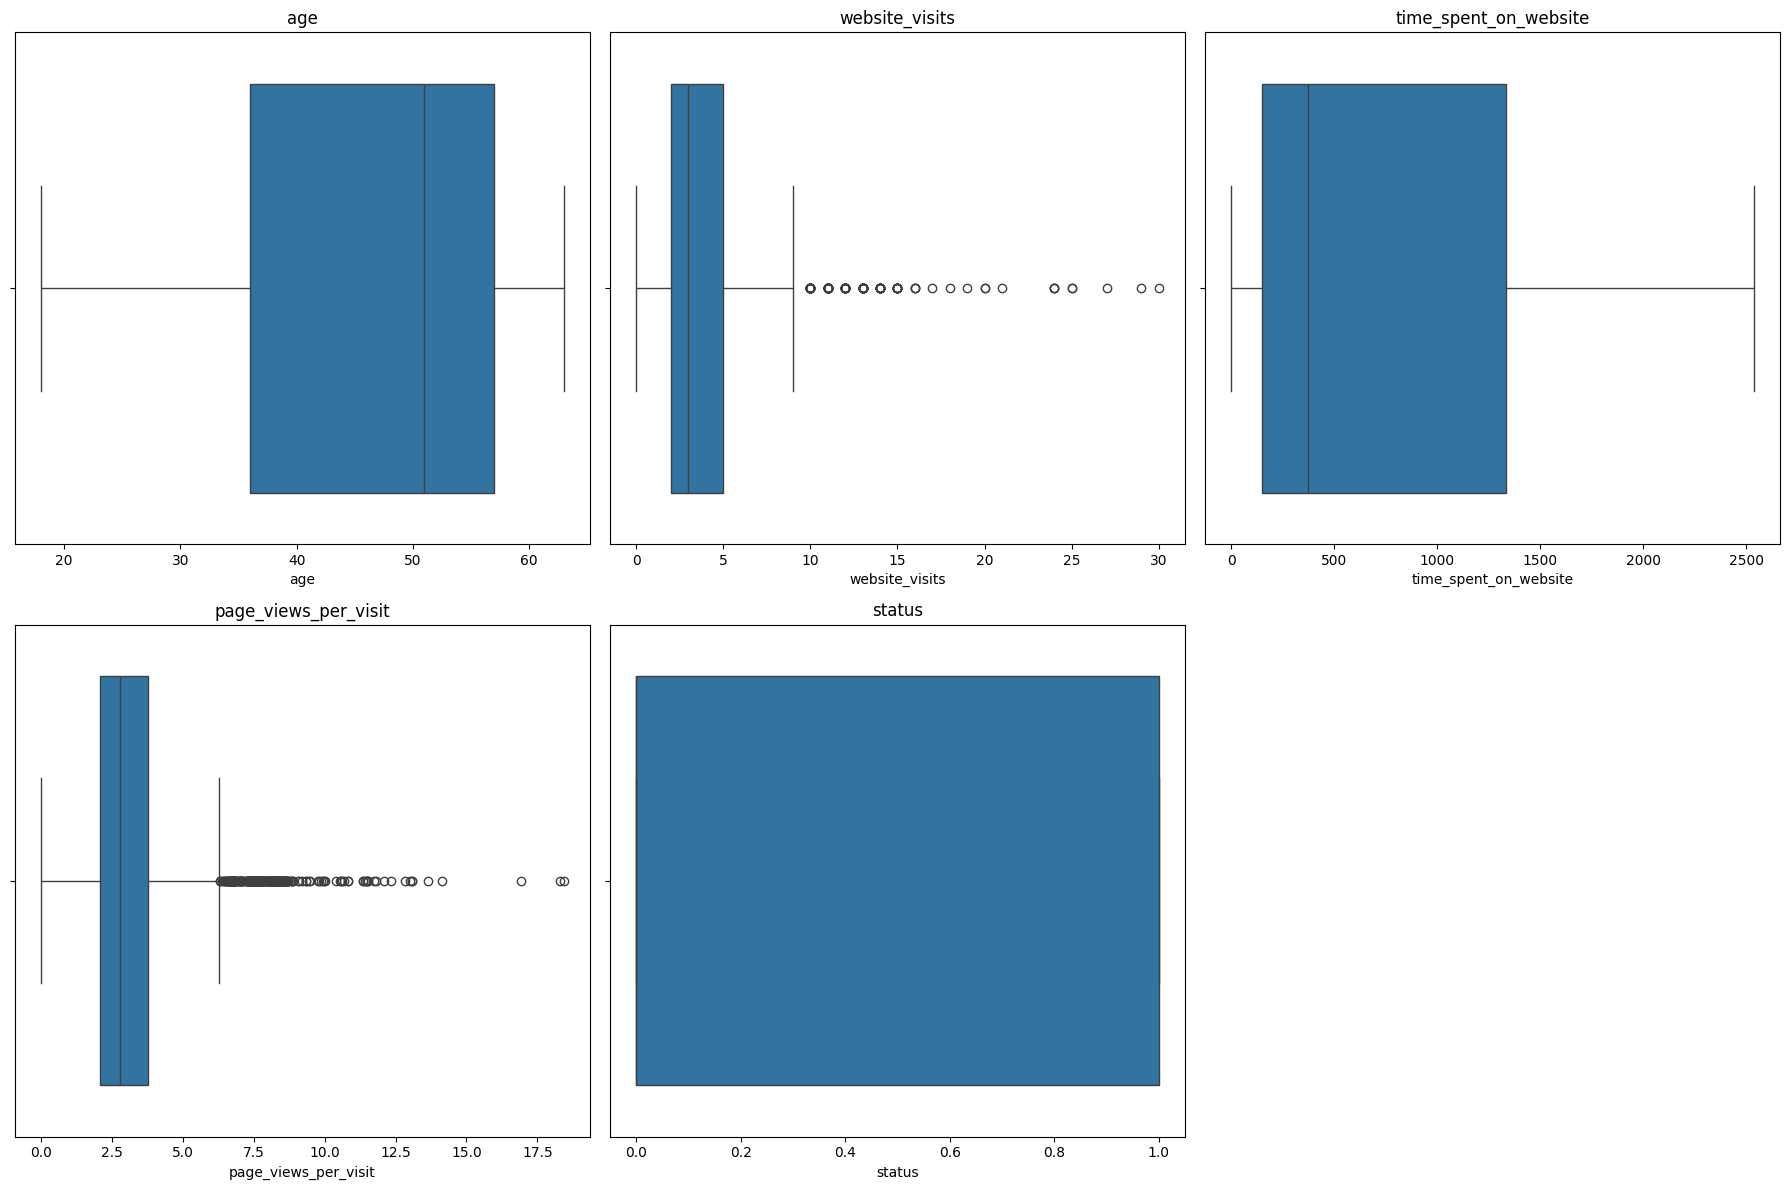

Number of outliers in age: 0
Number of outliers in website_visits: 154
Number of outliers in time_spent_on_website: 0
Number of outliers in page_views_per_visit: 257
Number of outliers in status: 0


In [ ]:
 # Check for the Outliers in the dataset
# 1st Step: create the list of numerical columns
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns
# 2nd Step: create a subplot and boxplot for visualization
plt.figure(figsize=(18, 12)) # Adjusted figure size to accommodate more subplots
for i, col in enumerate(numerical_columns):
    plt.subplot(2, 3, i + 1) # Changed to 2 rows, 3 columns to fit 5 plots
    sns.boxplot(x=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()
# 3rd Step: Create a function to count for the Outliers based on the IQR method
def count_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers.shape[0]
# 4th Step: Print out the number of outliers
for col in numerical_columns:
    num_outliers = count_outliers(data, col)
    print(f"Number of outliers in {col}: {num_outliers}")

As all the outliers was in the number of web visit and the page  views per visit, which still make sense ---> I decided not to delete or do anything about the outliers

In [ ]:
# Spliting the data to train and test based on the 70:30 ratio And spilitting the "status" column as a target variable from the predictor
X = data.drop(columns=["status"], axis = 1)
y = data["status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3228, 13)
Shape of test set :  (1384, 13)
Percentage of classes in training set:
status
0   0.70415
1   0.29585
Name: proportion, dtype: float64
Percentage of classes in test set:
status
0   0.69509
1   0.30491
Name: proportion, dtype: float64


## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
# Creat  a list of Categorical value
categorical_columns = data.select_dtypes(include=['object']).columns
# Printing number of count of each unique value in each column
for column in categorical_columns:
    print(f'Number of count of each unique value in each column {data[column].value_counts()}')
    print("-" * 50)

Number of count of each unique value in each column current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
Number of count of each unique value in each column first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
--------------------------------------------------
Number of count of each unique value in each column profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
Number of count of each unique value in each column last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
Number of count of each unique value in each column print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
Number of count of each

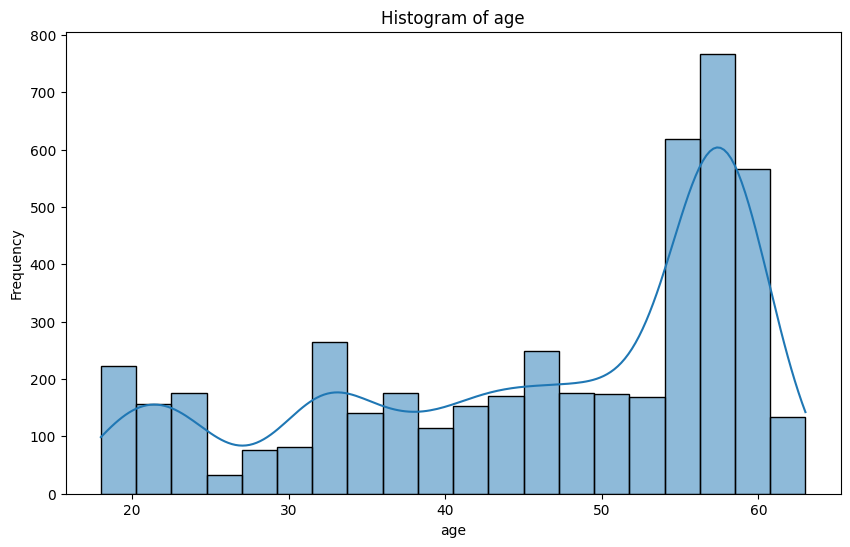

--------------------------------------------------


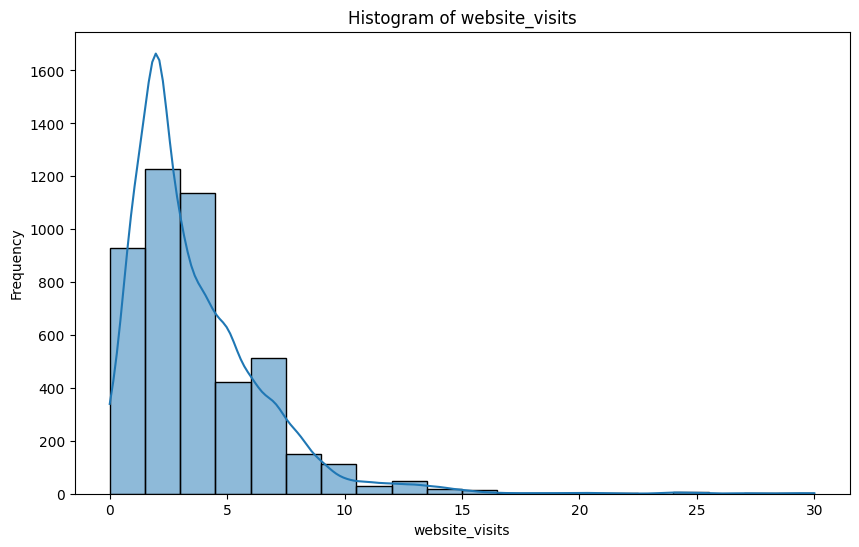

--------------------------------------------------


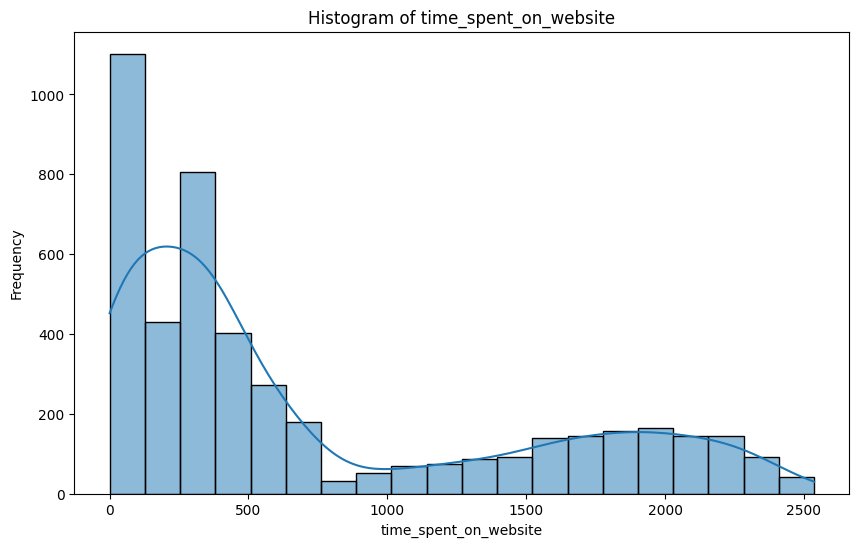

--------------------------------------------------


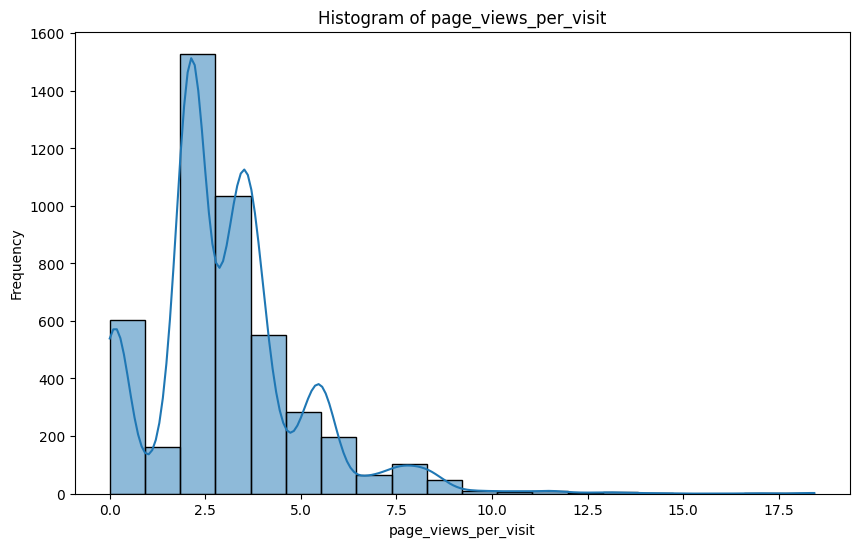

--------------------------------------------------


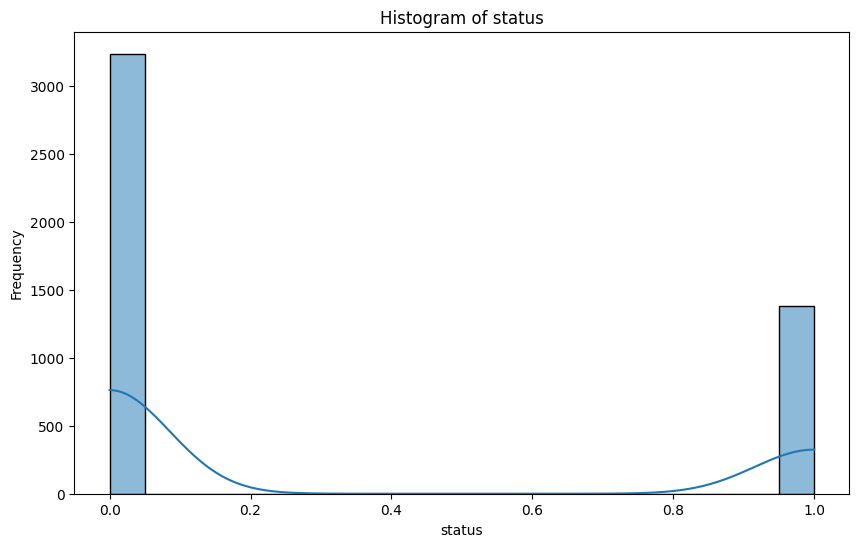

--------------------------------------------------


In [ ]:
# Observation on Numerical column by the histogram
for columns in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[columns], bins=20, kde=True)
    plt.title(f'Histogram of {columns}')
    plt.xlabel(columns)
    plt.ylabel('Frequency')
    plt.show()
    print("-" * 50)

**Obsevation**
Based on the histogram plot of all numerical value


*   Most of the age range from 50-60
*   Most of the website visits range from 0-5


*   Most of the time spent on website range from 0-375
*   Most of the page views per visit range from 0-5.0





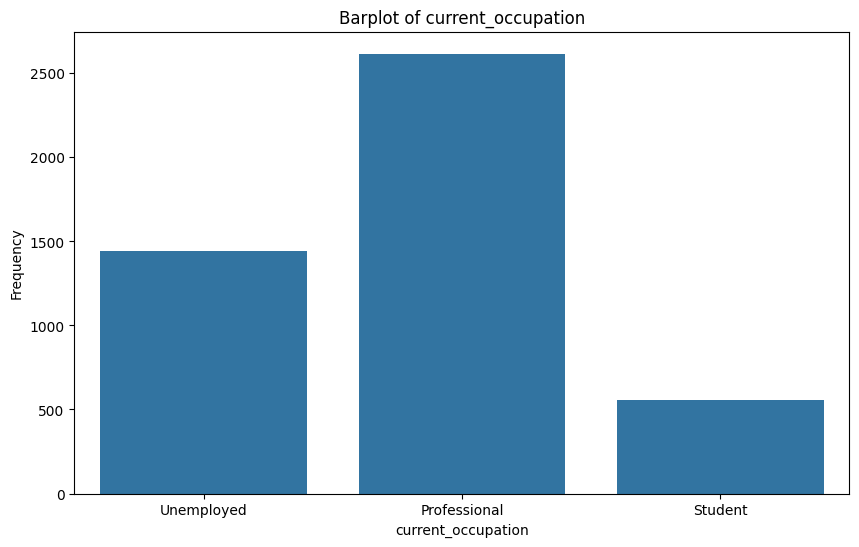

--------------------------------------------------


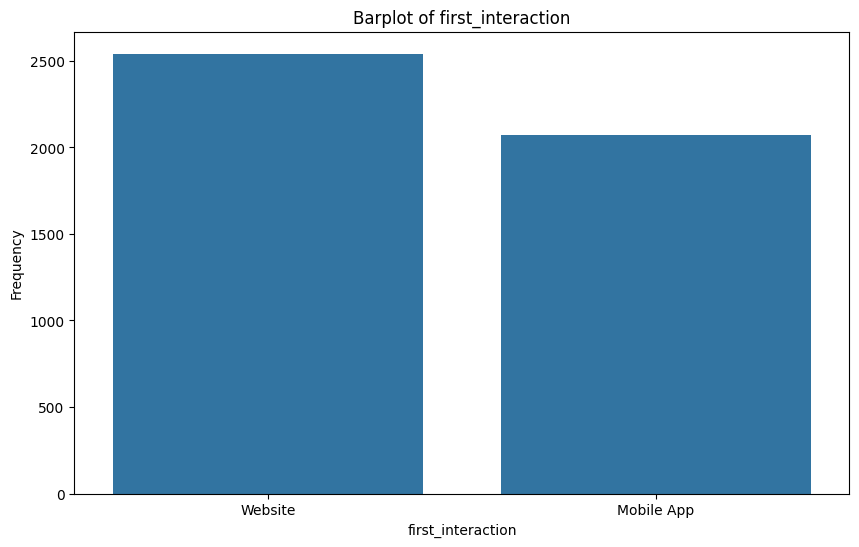

--------------------------------------------------


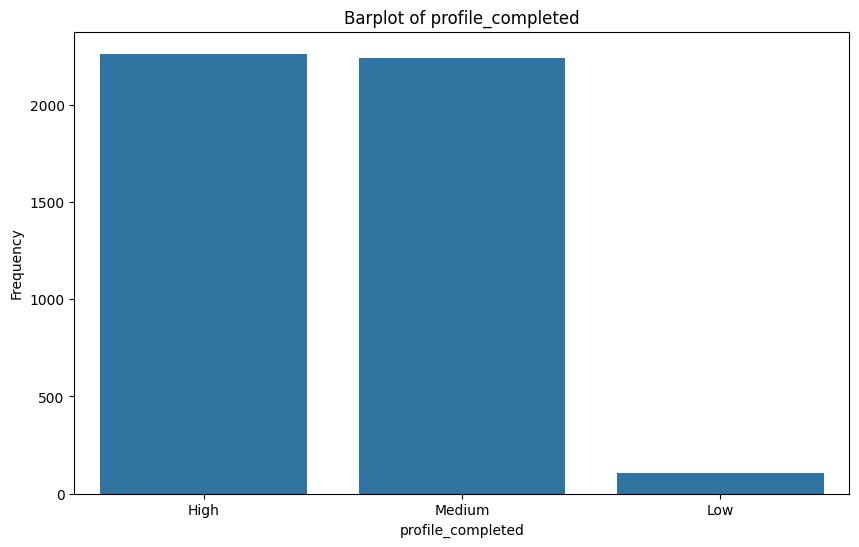

--------------------------------------------------


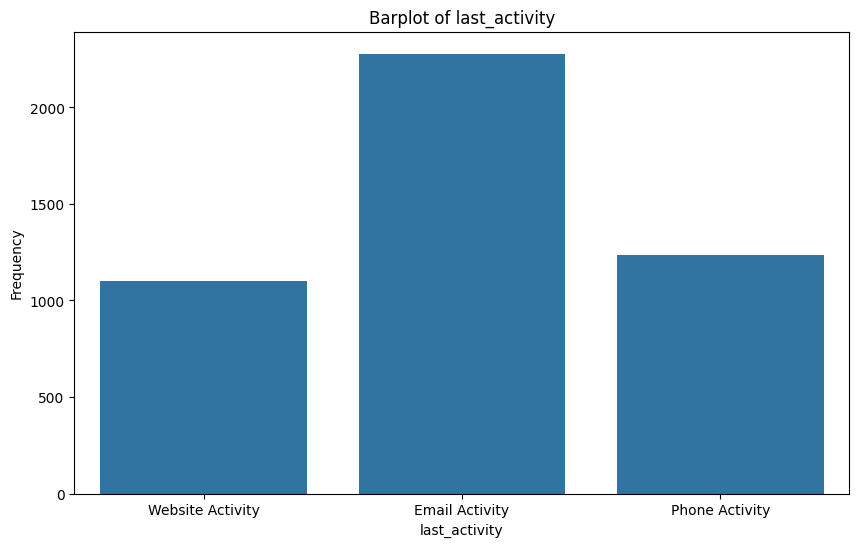

--------------------------------------------------


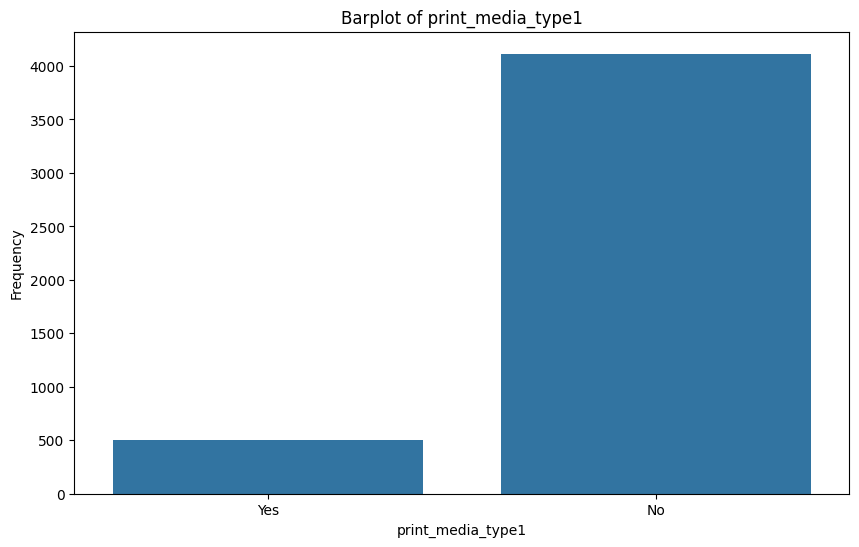

--------------------------------------------------


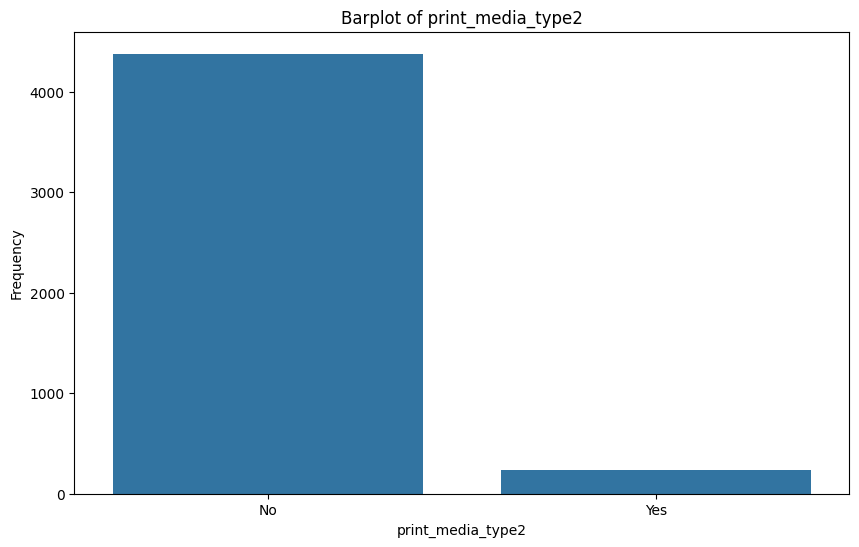

--------------------------------------------------


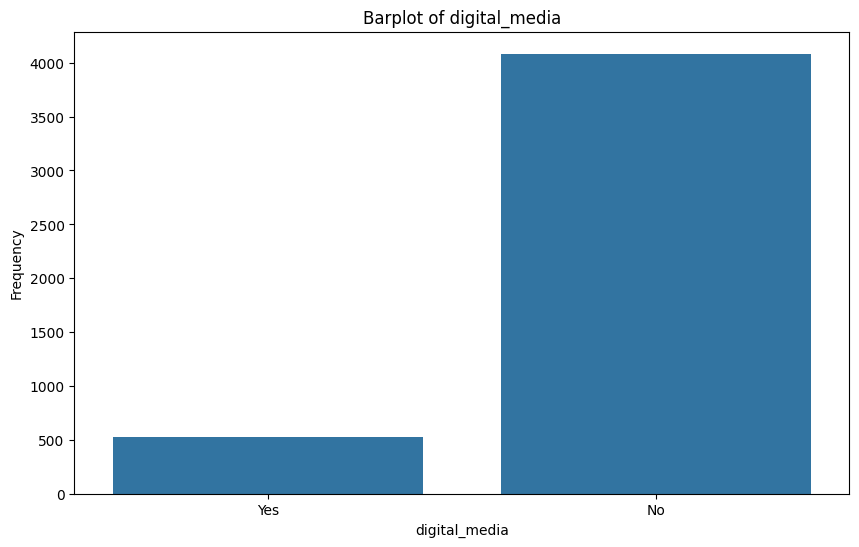

--------------------------------------------------


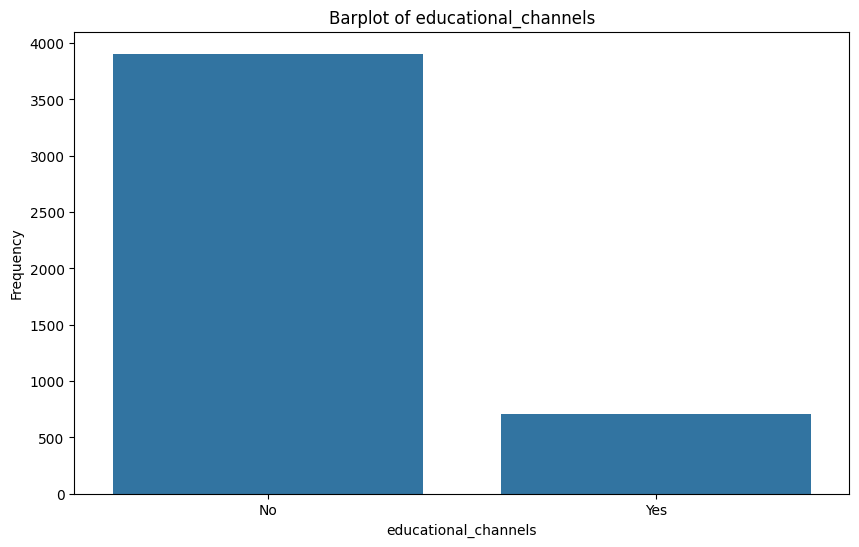

--------------------------------------------------


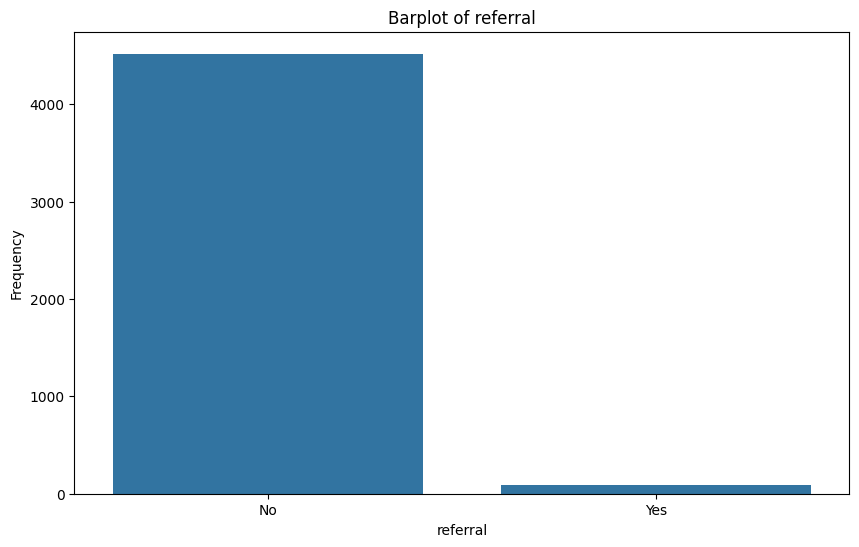

--------------------------------------------------


In [ ]:
# Obsevation for the Categorical column based on the barplot
for columns in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=columns)
    plt.title(f'Barplot of {columns}')
    plt.xlabel(columns)
    plt.ylabel('Frequency')
    plt.show()
    print("-" * 50)

**Observation:**


*   Most of the leads are professional
*   Most of the leads prefer the website as their first interaction rather than the mobile app


*   Most of the Profile completed are High and Medium (50-100%)
*   Most of the leads prefer the email activity as their last interaction







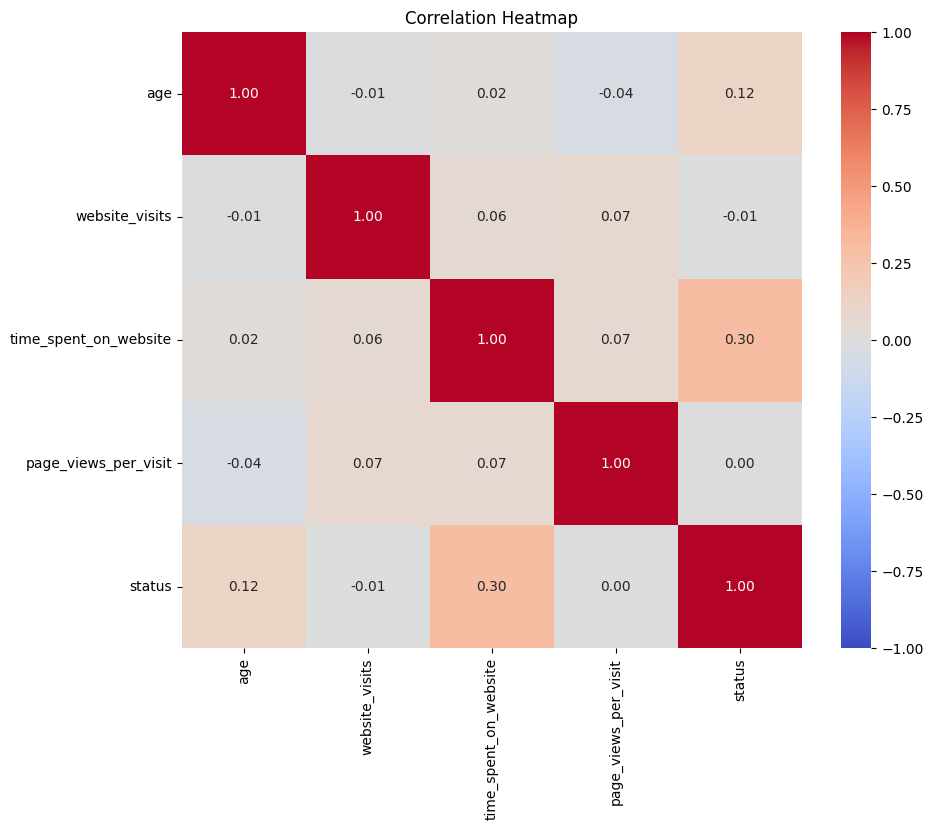

In [ ]:
# Create a heatmap for finding a correlation between numerical variable
plt.figure(figsize=(10, 8))
sns.heatmap(data[numerical_columns].corr(), annot=True,vmin=-1 ,vmax=1,fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

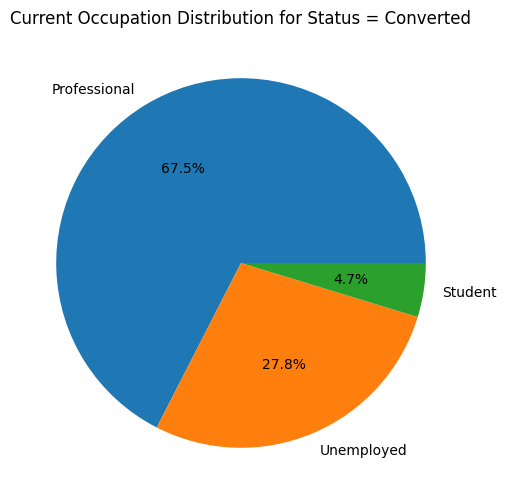

--------------------------------------------------


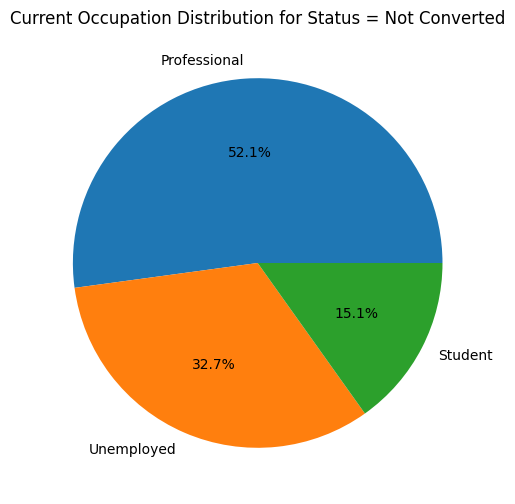

--------------------------------------------------


In [ ]:
# Convert the 1 and 0 outcome to categorical data in the "Status" columns
data_copy['status'] = data_copy['status'].map({0: 'Not Converted', 1: 'Converted'})
# Find out how current occupation affect lead status by a pie chart
for s_value in data_copy['status'].unique():
    plt.figure(figsize=(10, 6))
    # Filter data for the current status value
    subset_data = data[data_copy['status'] == s_value]
    # Plot current_occupation distribution for this status
    subset_data['current_occupation'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'Current Occupation Distribution for Status = {s_value}')
    plt.ylabel('')
    plt.show()
    print("-" * 50) # Add a separator for clarity

**Observation:**


*   The Converted Status mostly have professional lead and have minor converted count in student
*   However, when look at the Not Converted Status

1.   The percentage of Professional decreased
2.   The percentage of Unemployted increased
3.   The percentage of Student increased


---
--> The occupation really affect the lead status











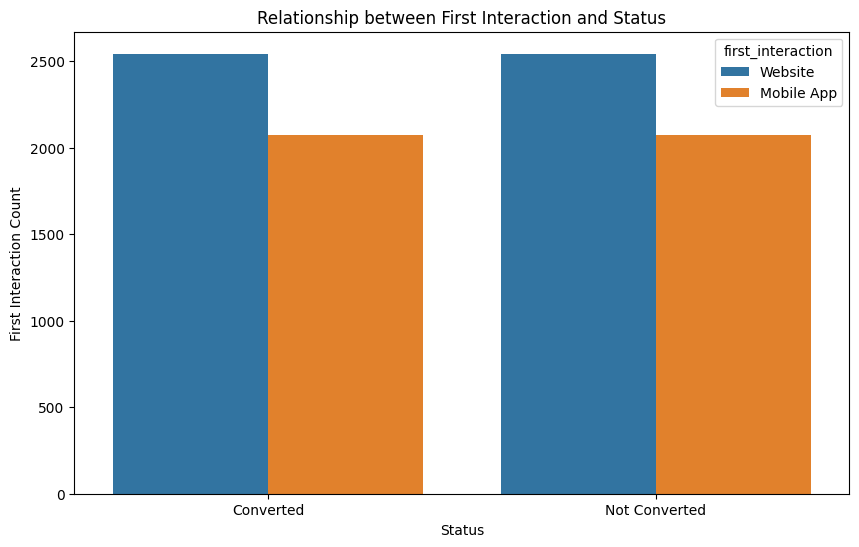

In [ ]:
# Create a count variable for the first interaction variable
first_interaction_count = data_copy['first_interaction'].value_counts()
data_copy['first_interaction_count'] = data_copy['first_interaction'].map(first_interaction_count)
# Find the relationship between the first interaction and the Status by the barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=data_copy, x='status', y='first_interaction_count', hue='first_interaction')
plt.title('Relationship between First Interaction and Status')
plt.ylabel('First Interaction Count')
plt.xlabel('Status')
plt.show()



**Observation:**Both the Status have higher amount of Website as a first interaction --->> there no relationship between the the first interaction status and the status

Text(0, 0.5, 'Count')

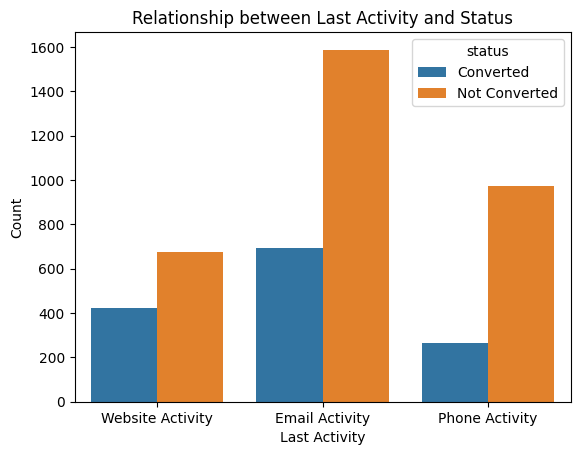

In [ ]:
# Finding which mode that work best to interact with prospects by using the Stacked Bar
sns.countplot(x='last_activity', hue= 'status', data= data_copy)
plt.title('Relationship between Last Activity and Status')
plt.xlabel('Last Activity')
plt.ylabel('Count')


**Obsevation:** The amount of email activity that used as a last interaction activiy was outweight the rest with both the status. --> email help boost the converted also the not converted

In [ ]:
# Finding which channels have the highest lead conversion rate
# 1st Step: create a list of channels that Extraalearn use
channels = ['print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']
# 2nd Step: Calculate the conversion rate based on the yes value of channels vs the status (1,0)
for channel in channels:
    channel_data = data_copy[data_copy[channel] == 'Yes']
    # Map 'Converted' to 1 and 'Not Converted' to 0 for mean calculation
    converted_status = channel_data['status'].map({'Not Converted': 0, 'Converted': 1})
    conversion_rate = converted_status.mean() * 100
    print(f"Conversion rate for {channel}: {conversion_rate:.2f}%")

Conversion rate for print_media_type1: 31.99%
Conversion rate for print_media_type2: 32.19%
Conversion rate for digital_media: 31.88%
Conversion rate for educational_channels: 27.94%
Conversion rate for referral: 67.74%


**Observation:** The refferal status have the highest conversion rate

Text(0, 0.5, 'Profile Completed Count')

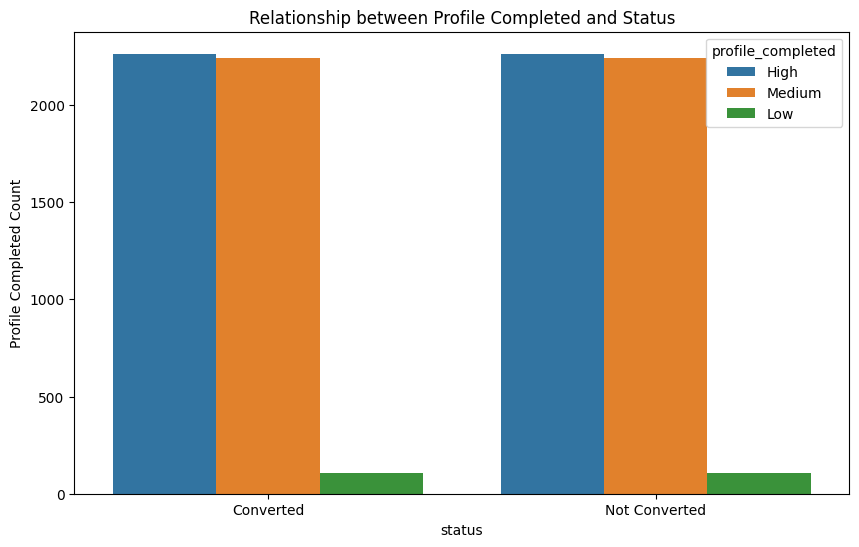

In [ ]:
# Does having more details about a prospect increase the chances of conversion?
# 1st stepe: create a variable for the profile_completed
profile_completed_count = data_copy['profile_completed'].value_counts()
data_copy['profile_completed_count'] = data_copy['profile_completed'].map(profile_completed_count)
# 2nd Step: Find the relationship between the profile_completed and the Status by the barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=data_copy, x='status', y='profile_completed_count', hue='profile_completed')
plt.title('Relationship between Profile Completed and Status')
plt.ylabel('Profile Completed Count')

**Obsevation:** Both the status have the same amount of profile completed number in each category. ---> having more details about a prospect the chances of conversion

## Building a Decision Tree model

In [ ]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)


In [ ]:
# Function to evaluate the model
def metrics_score(actual, predicted):
    print(f"Accuracy Score: {accuracy_score(actual, predicted):.2f}")
    print(f"Precision Score: {precision_score(actual, predicted):.2f}")
    print(f"Recall Score: {recall_score(actual, predicted):.2f}")
    print(f"F1 Score: {f1_score(actual, predicted):.2f}")

In [ ]:
# Built a decision tree
d_tree = DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train_encoded, y_train)
# Performance on the training data
y_pred_train1 = d_tree.predict(X_train_encoded)
print("Performance on the training data")
print("Metrics score:", metrics_score(y_train, y_pred_train1))
# Performance on the testing data
y_pred_test1 = d_tree.predict(X_test_encoded)
print("Performance on the testing data")
print("Metrics score:", metrics_score(y_test, y_pred_test1))

Performance on the training data
Accuracy Score: 1.00
Precision Score: 1.00
Recall Score: 1.00
F1 Score: 1.00
Metrics score: None
Performance on the testing data
Accuracy Score: 0.81
Precision Score: 0.69
Recall Score: 0.70
F1 Score: 0.70
Metrics score: None


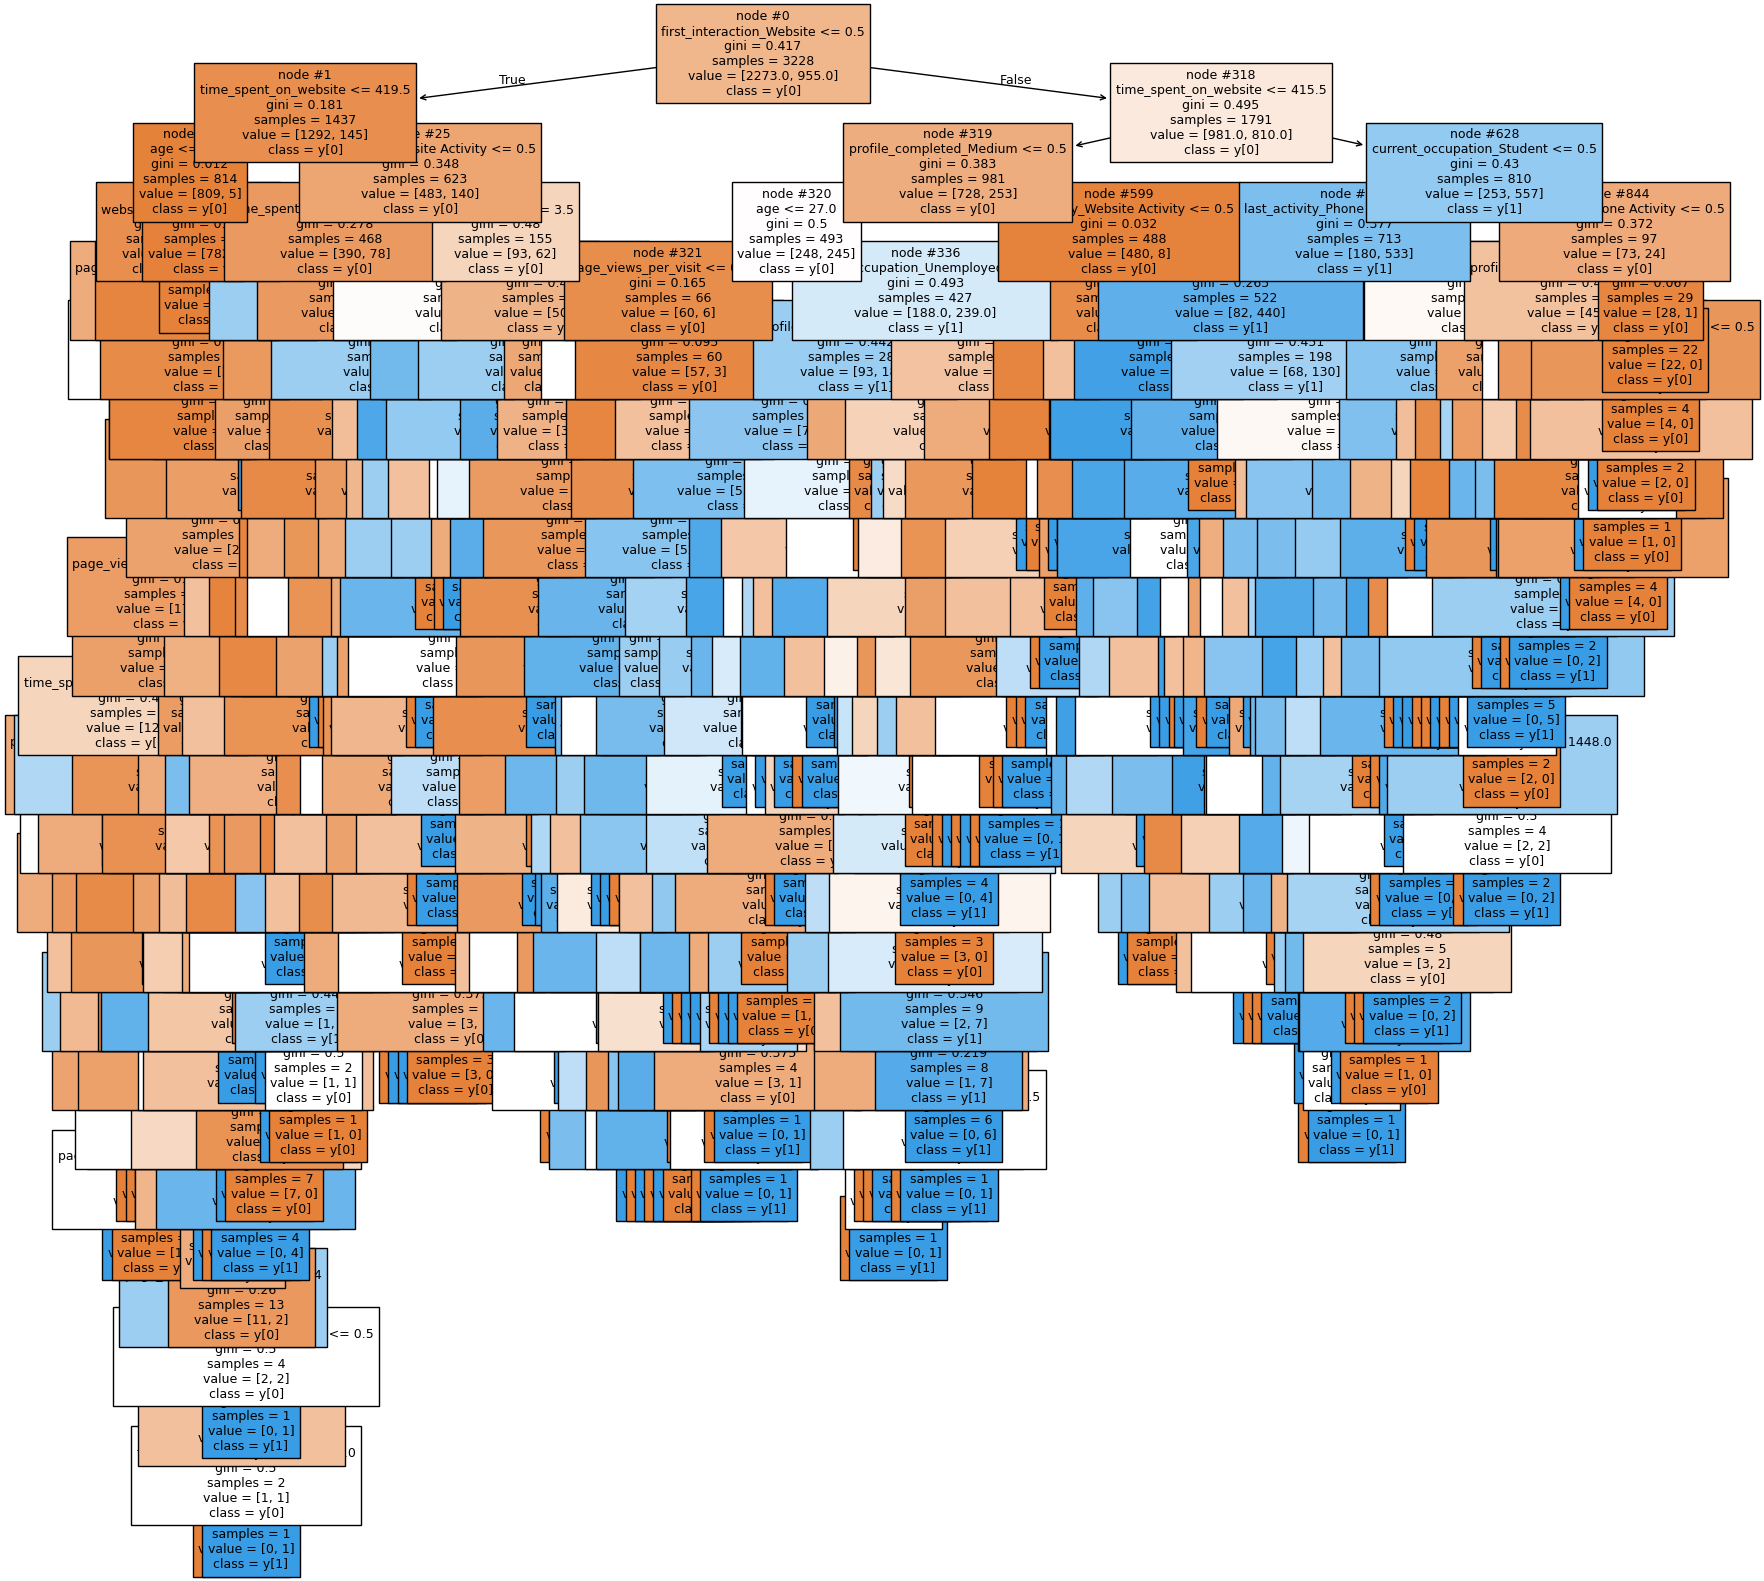

                                     0
time_spent_on_website          0.27784
first_interaction_Website      0.14637
page_views_per_visit           0.12710
profile_completed_Medium       0.12452
age                            0.08712
website_visits                 0.05096
current_occupation_Unemployed  0.04078
last_activity_Phone Activity   0.03679
current_occupation_Student     0.03328
last_activity_Website Activity 0.02254
profile_completed_Low          0.01944
digital_media_Yes              0.00904
educational_channels_Yes       0.00806
print_media_type1_Yes          0.00775
referral_Yes                   0.00515
print_media_type2_Yes          0.00328


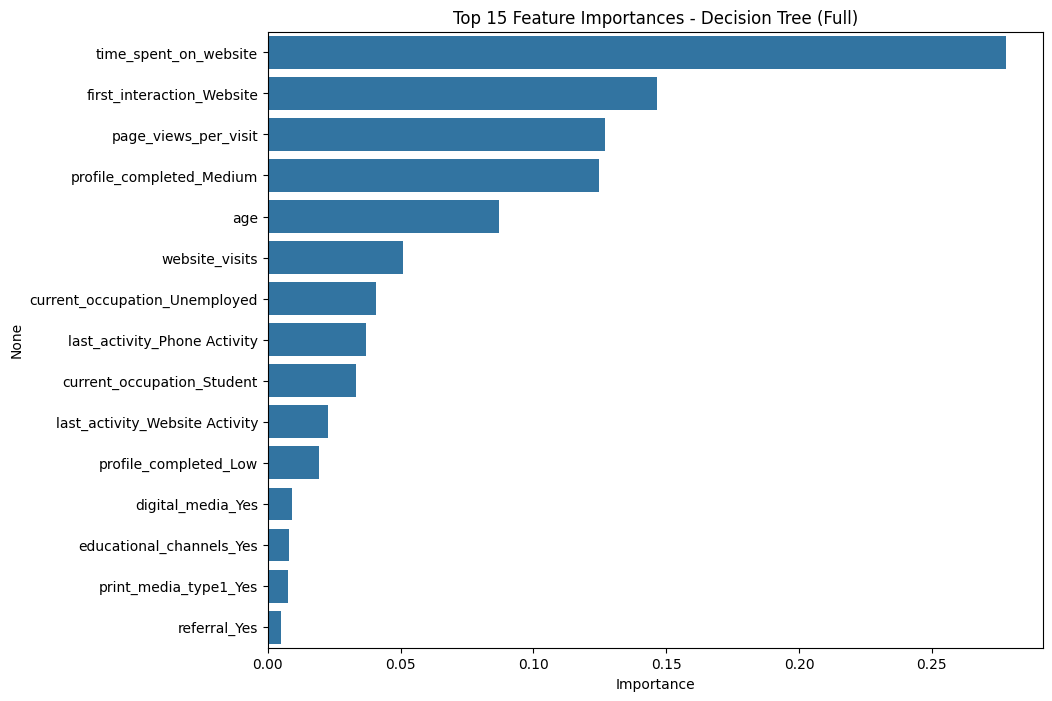

In [ ]:
d_tree.fit(X_train_encoded, y_train)

# Visualize the decision tree
features = list(X_train_encoded.columns) # Corrected to use columns from X_train_encoded

plt.figure(figsize = (20, 20))

tree.plot_tree(d_tree, feature_names = features, filled = True, fontsize = 9, node_ids = True, class_names = True)

plt.show()
# Important features of tree building
print(pd.DataFrame(pd.Series(d_tree.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)))
important_feature = pd.Series(d_tree.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=important_feature.values[:15], y=important_feature.index[:15])
plt.title("Top 15 Feature Importances - Decision Tree (Full)")
plt.xlabel("Importance")
plt.show()

**Observation:**

* The un-pruned Decision Tree achieves a perfect score (Accuracy = Recall = Precision = F1 = 1.0) on the training data, which is a classic sign of **overfitting** - the tree has essentially memorized the training data.
* On the test data the performance drops noticeably, confirming that the model does not generalize well and needs to be pruned.


*   Time spent on the website and first_interaction_website are the most important features, followed by profile_completed, age, and last_activity




## Do we need to prune the tree?

In [ ]:
 # Choose the type of classifier
d_tree_tuned = DecisionTreeClassifier(random_state = 7, class_weight = {0: 0.3, 1: 0.7})

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 10),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(d_tree_tuned, parameters, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(X_train_encoded, y_train)

# Set the classifier to the best combination of parameters
d_tree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
d_tree_tuned.fit(X_train_encoded, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, criterion='entropy',
                       max_depth=np.int64(3), min_samples_leaf=5,
                       random_state=7)

In [ ]:
# Checking performance on the training data
y_pred_train3 = d_tree_tuned.predict(X_train_encoded)
print("Performance on the training data")
print("Metrics score:", metrics_score(y_train, y_pred_train3))
# Checking performance on the testing data
y_pred_test3 = d_tree_tuned.predict(X_test_encoded)
print("Performance on the testing data")
print("Metrics score:", metrics_score(y_test, y_pred_test3))

Performance on the training data
Accuracy Score: 0.80
Precision Score: 0.62
Recall Score: 0.88
F1 Score: 0.73
Metrics score: None
Performance on the testing data
Accuracy Score: 0.80
Precision Score: 0.62
Recall Score: 0.86
F1 Score: 0.72
Metrics score: None


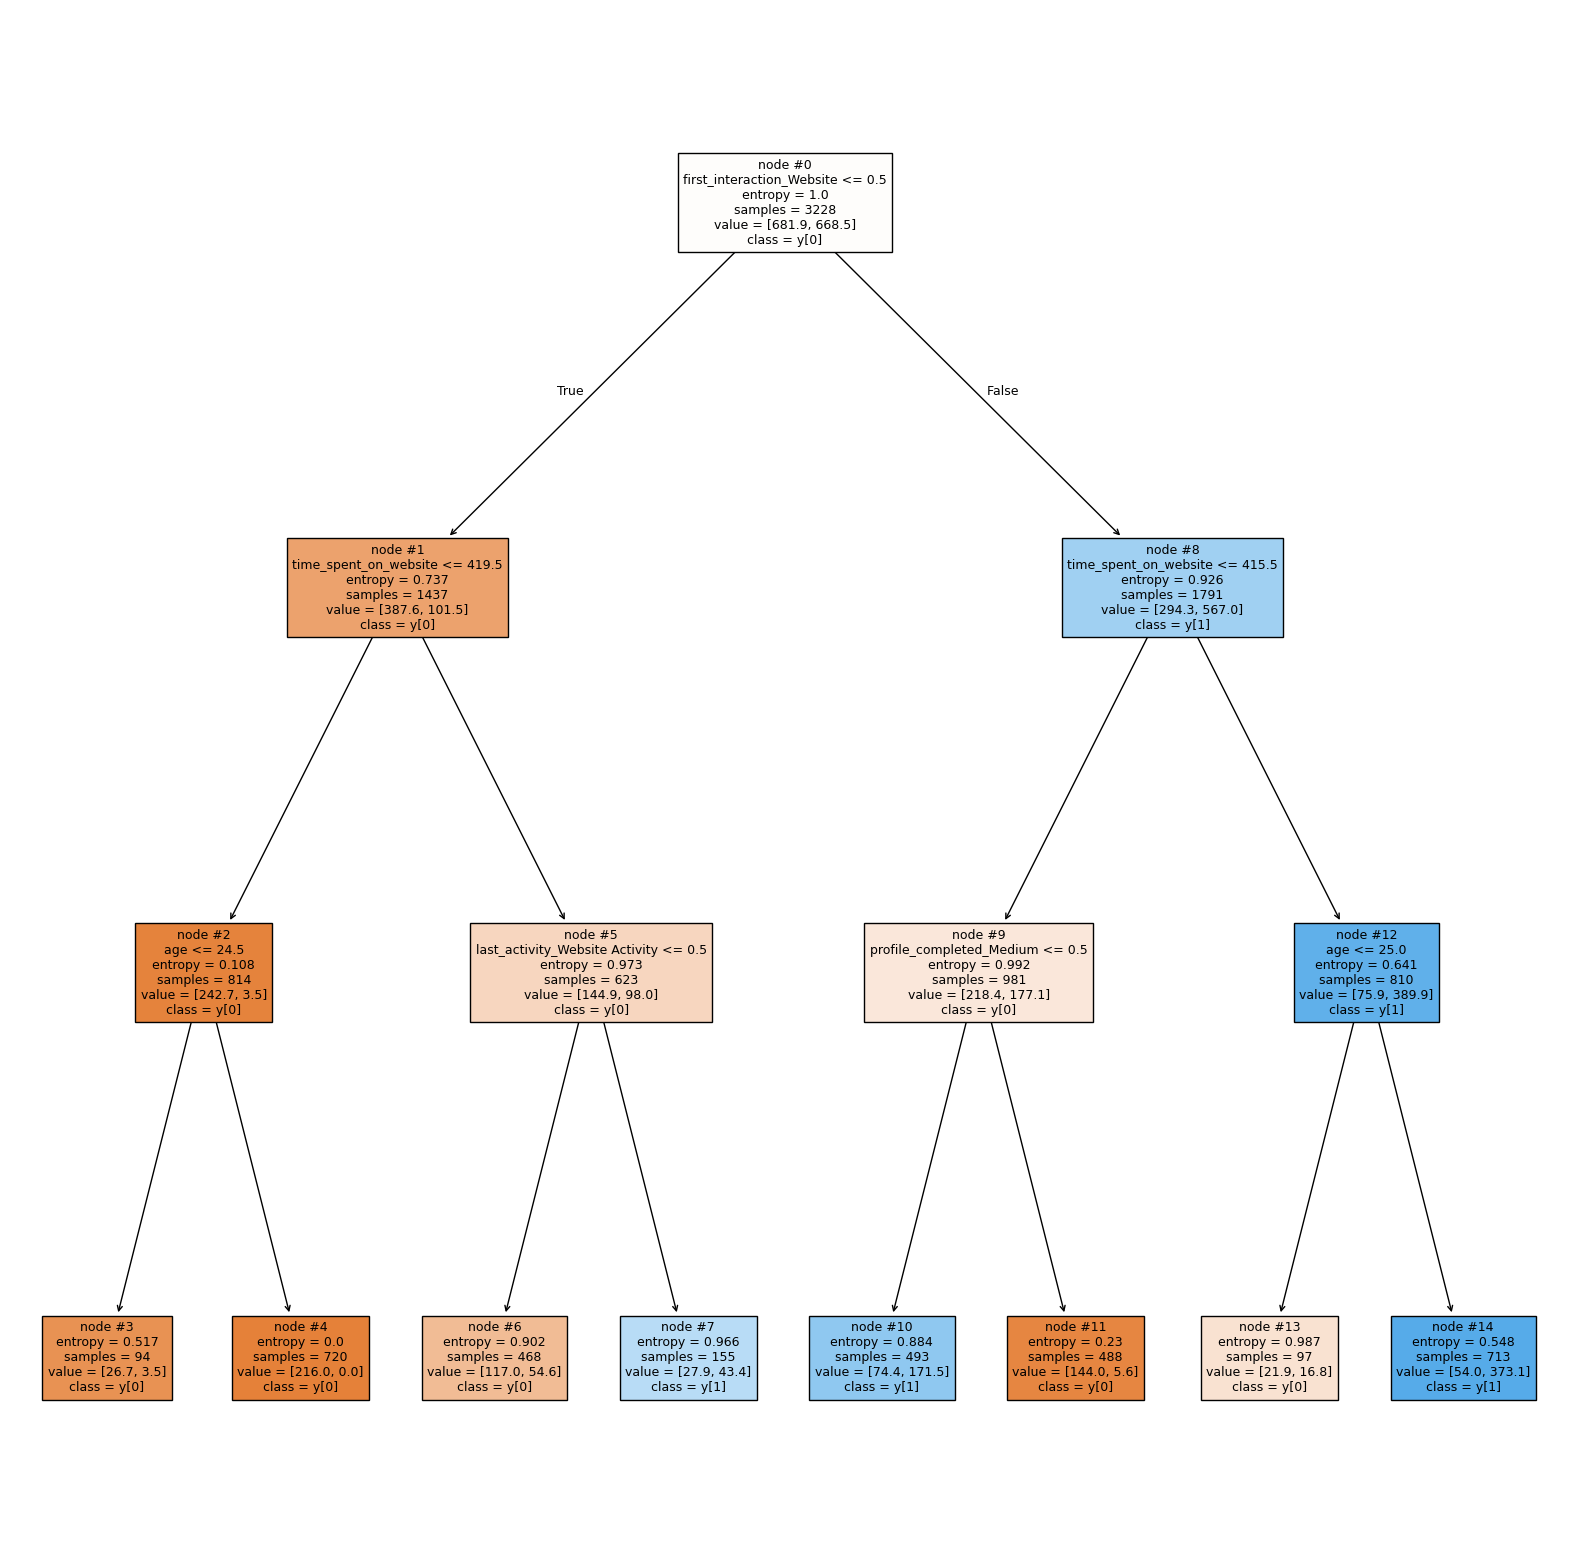

In [ ]:
# Visualize the pruned decision tree
features_pruned = list(X_train_encoded.columns) # Corrected to use columns from X_train_encoded

plt.figure(figsize = (20, 20))

tree.plot_tree(d_tree_tuned, feature_names = features_pruned, filled = True, fontsize = 9, node_ids = True, class_names = True)

plt.show()

                                     0
time_spent_on_website          0.34814
first_interaction_Website      0.32718
profile_completed_Medium       0.23927
age                            0.06389
last_activity_Website Activity 0.02151
current_occupation_Student     0.00000
page_views_per_visit           0.00000
website_visits                 0.00000
profile_completed_Low          0.00000
current_occupation_Unemployed  0.00000
last_activity_Phone Activity   0.00000
print_media_type1_Yes          0.00000
print_media_type2_Yes          0.00000
digital_media_Yes              0.00000
educational_channels_Yes       0.00000
referral_Yes                   0.00000


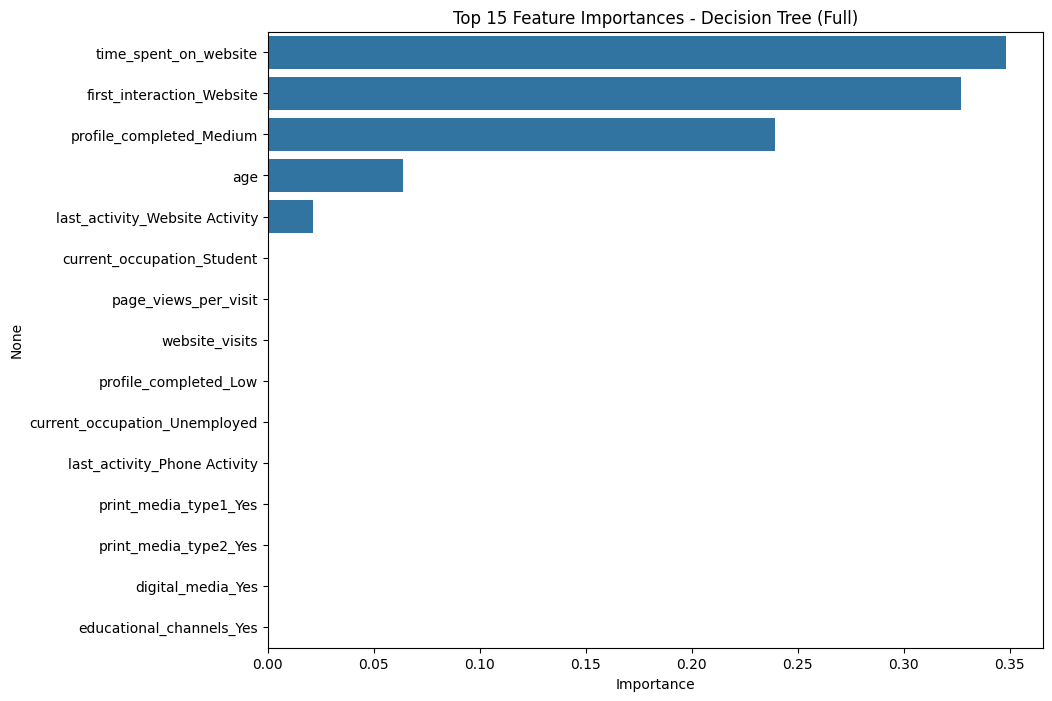

In [ ]:

# Important features of pruned tree building
print(pd.DataFrame(pd.Series(d_tree_tuned.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)))
important_feature_tuned = pd.Series(d_tree_tuned.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=important_feature_tuned.values[:15], y=important_feature_tuned.index[:15])
plt.title("Top 15 Feature Importances - Decision Tree (Full)")
plt.xlabel("Importance")
plt.show()

## Building a Random Forest model

In [ ]:
# Fitting the random forest tree classifier on the training data
r_forest = RandomForestClassifier(random_state=1)
r_forest.fit(X_train_encoded, y_train)
# Checking the performance on the training data
y_pred_train2 = r_forest.predict(X_train_encoded)
print("Performance on the training data")
print("Metrics score:", metrics_score(y_train, y_pred_train2))
# Checking the performance on the testing data
y_pred_test2 = r_forest.predict(X_test_encoded)
print("Performance on the testing data")
print("Metrics score:", metrics_score(y_test, y_pred_test2))

Performance on the training data
Accuracy Score: 1.00
Precision Score: 1.00
Recall Score: 1.00
F1 Score: 1.00
Metrics score: None
Performance on the testing data
Accuracy Score: 0.84
Precision Score: 0.78
Recall Score: 0.68
F1 Score: 0.73
Metrics score: None


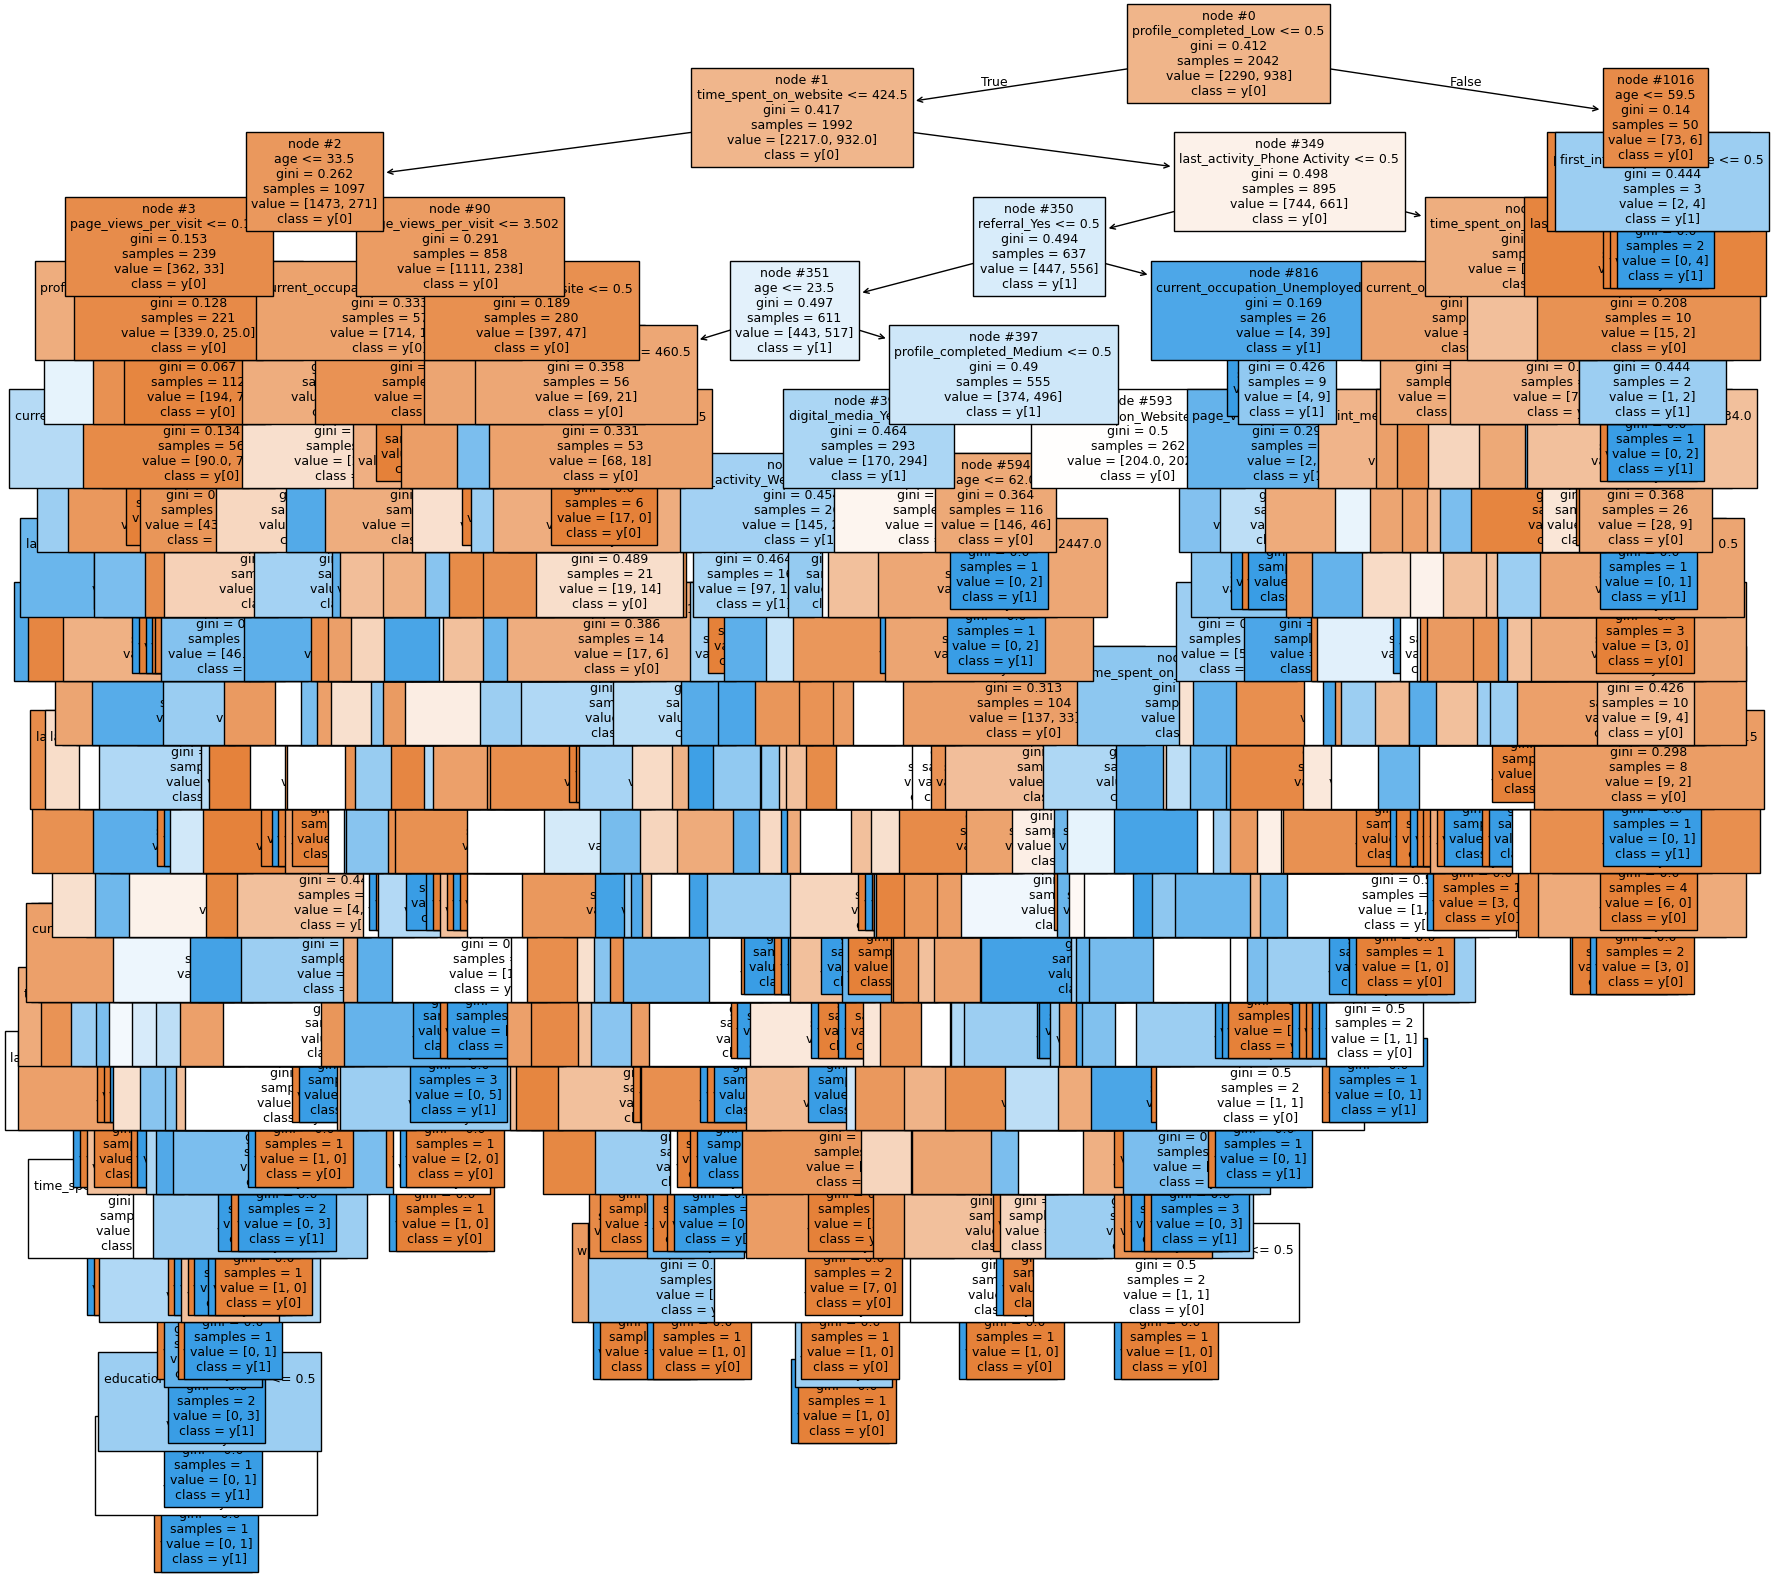

In [ ]:
# Visualize the random forest
features = list(X_train_encoded.columns) # Corrected to use columns from X_train_encoded

plt.figure(figsize = (20, 20))

# To visualize a Random Forest, we can plot one of its individual decision trees
tree.plot_tree(r_forest.estimators_[0]
                , feature_names = features, filled = True, fontsize = 9, node_ids = True, class_names = True)

plt.show()

**Observation:**

* The un-pruned Random forest achieves a perfect score (Accuracy = Recall = Precision = F1 = 1.0) on the training data, which is a classic sign of **overfitting**
* On the test data the performance drops noticeably, confirming that the model does not generalize well and needs to be pruned.

## Do we need to prune the tree?

In [ ]:
r_forest_tuned = RandomForestClassifier(random_state = 7, class_weight = {0: 0.3, 1: 0.7})
# Grid of parameters to chose from
parameters = {"n_estimators": [110, 120],
    "max_depth": [6, 7],
    "min_samples_leaf": [20, 25],
    "max_features": [0.8, 0.9],
    "max_samples": [0.9, 1],
    "class_weight": ["balanced",{0: 0.3, 1: 0.7}]
             }
rf_scorer = metrics.make_scorer(recall_score, pos_label = 1)
grid_obj = GridSearchCV(r_forest_tuned, parameters, scoring = rf_scorer, cv = 5)
grid_obj = grid_obj.fit(X_train_encoded, y_train)
# Set the classifier to the best combination of parameters
r_forest_tuned = grid_obj.best_estimator_
# Fit the best algorithm to the data
r_forest_tuned.fit(X_train_encoded, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=6, max_features=0.8,
                       max_samples=0.9, min_samples_leaf=20, n_estimators=120,
                       random_state=7)

In [ ]:
# Performance on the training data
y_pred_train4 = r_forest_tuned.predict(X_train_encoded)
print("Performance on the training data")
print("Metrics score:", metrics_score(y_train, y_pred_train4))
# Performance on the testing data
y_pred_test4 = r_forest_tuned.predict(X_test_encoded)
print("Performance on the testing data")
print("Metrics score:", metrics_score(y_test, y_pred_test4))



Performance on the training data
Accuracy Score: 0.84
Precision Score: 0.69
Recall Score: 0.87
F1 Score: 0.77
Metrics score: None
Performance on the testing data
Accuracy Score: 0.84
Precision Score: 0.69
Recall Score: 0.84
F1 Score: 0.76
Metrics score: None


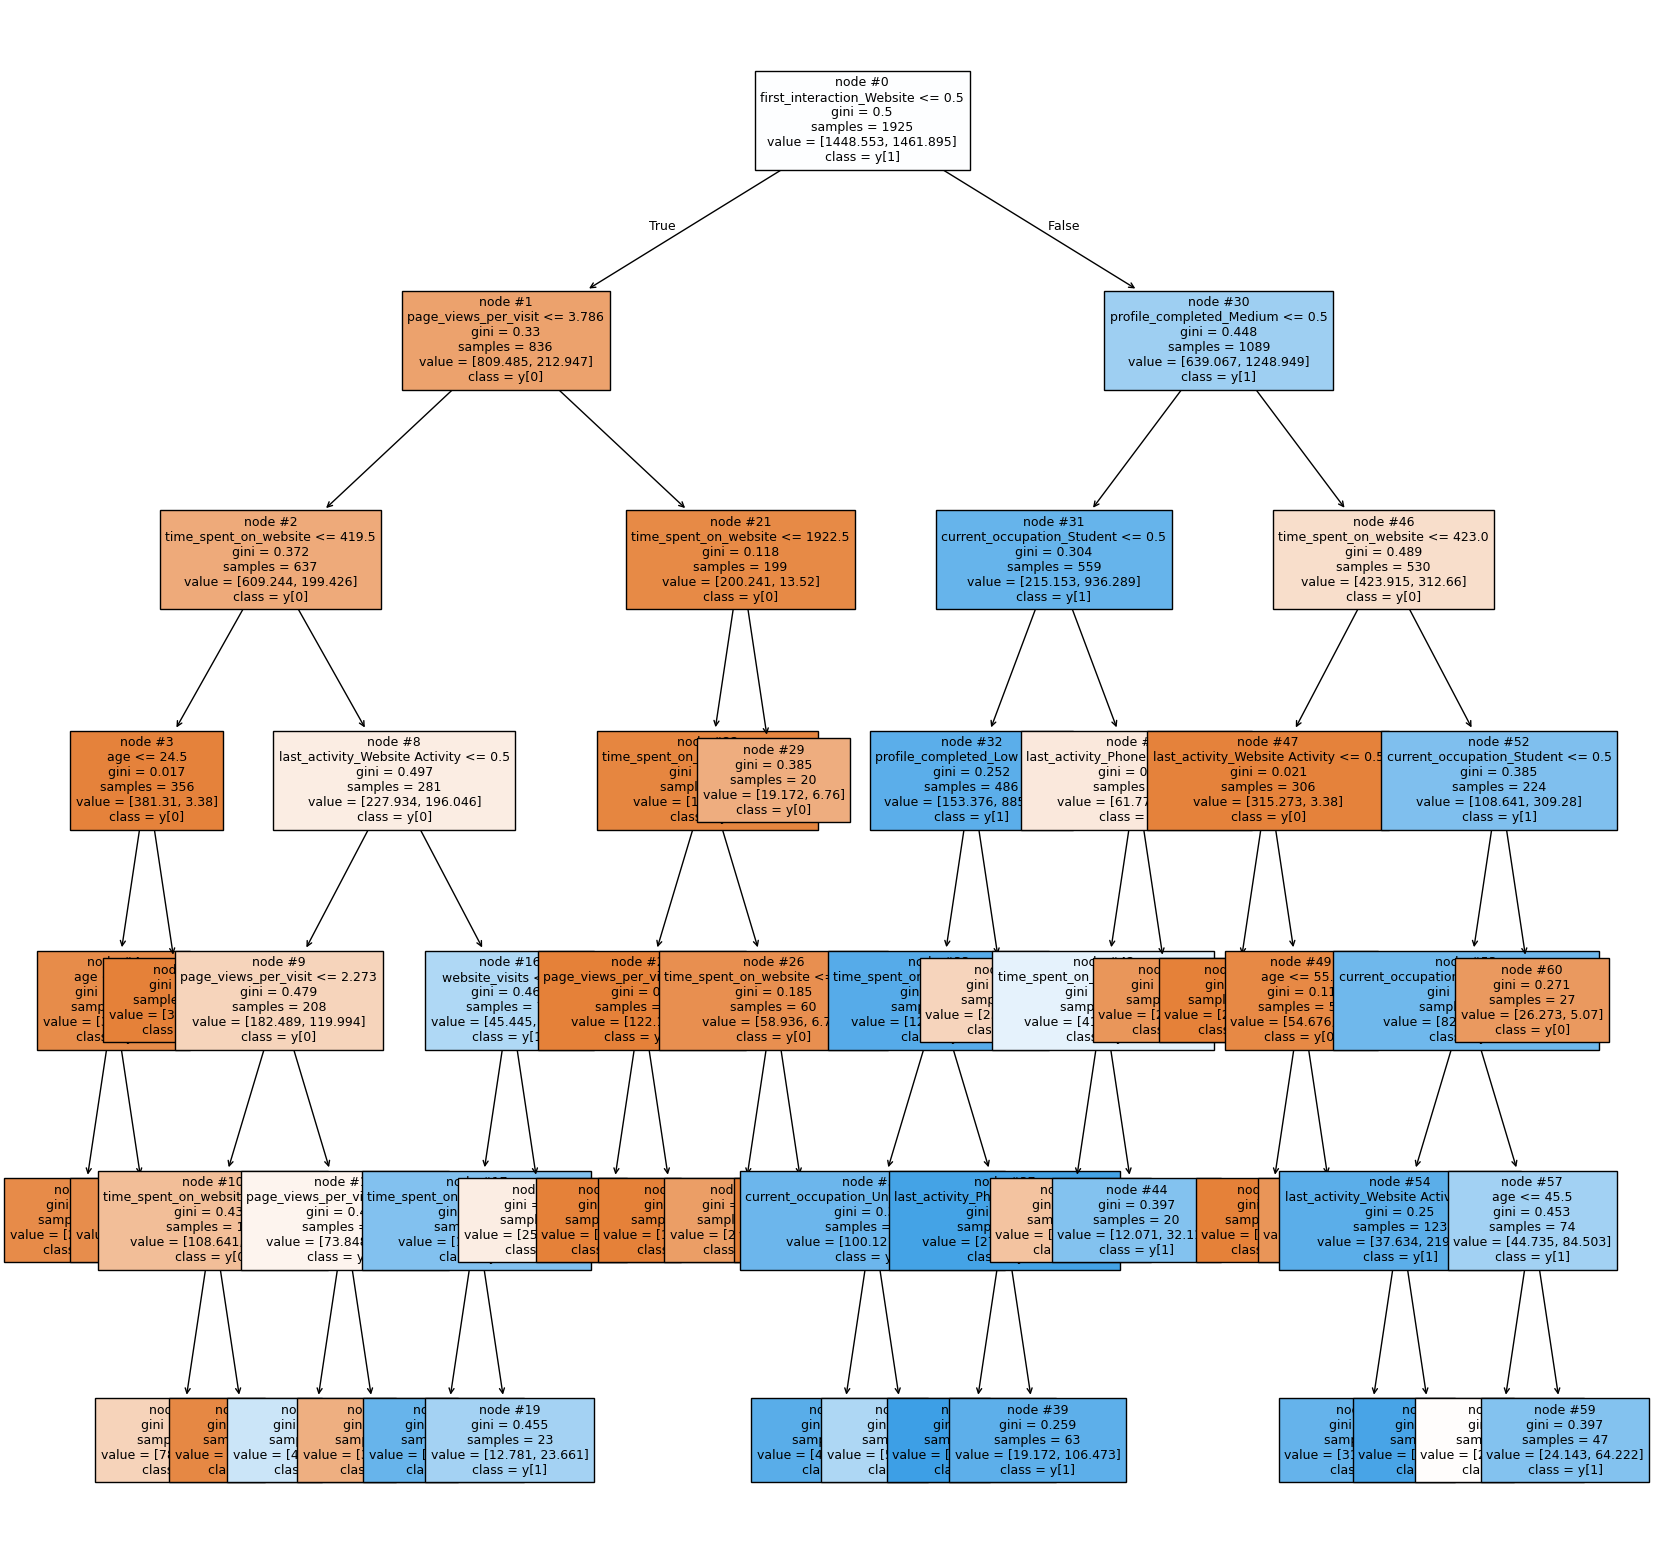

In [ ]:
# Visualize the pruned random forest
features_rf_pruned = list(X_train_encoded.columns) # Corrected to use columns from X_train_encoded

plt.figure(figsize = (20, 20))

# To visualize a Random Forest, we can plot one of its individual decision trees
tree.plot_tree(r_forest_tuned.estimators_[0]
                , feature_names = features_rf_pruned, filled = True, fontsize = 9, node_ids = True, class_names = True)

plt.show()

                                     0
first_interaction_Website      0.31767
time_spent_on_website          0.29399
profile_completed_Medium       0.20267
age                            0.05185
last_activity_Phone Activity   0.03129
current_occupation_Unemployed  0.02668
last_activity_Website Activity 0.02387
current_occupation_Student     0.02170
page_views_per_visit           0.01542
website_visits                 0.00935
profile_completed_Low          0.00365
educational_channels_Yes       0.00136
print_media_type1_Yes          0.00027
digital_media_Yes              0.00015
print_media_type2_Yes          0.00008
referral_Yes                   0.00000


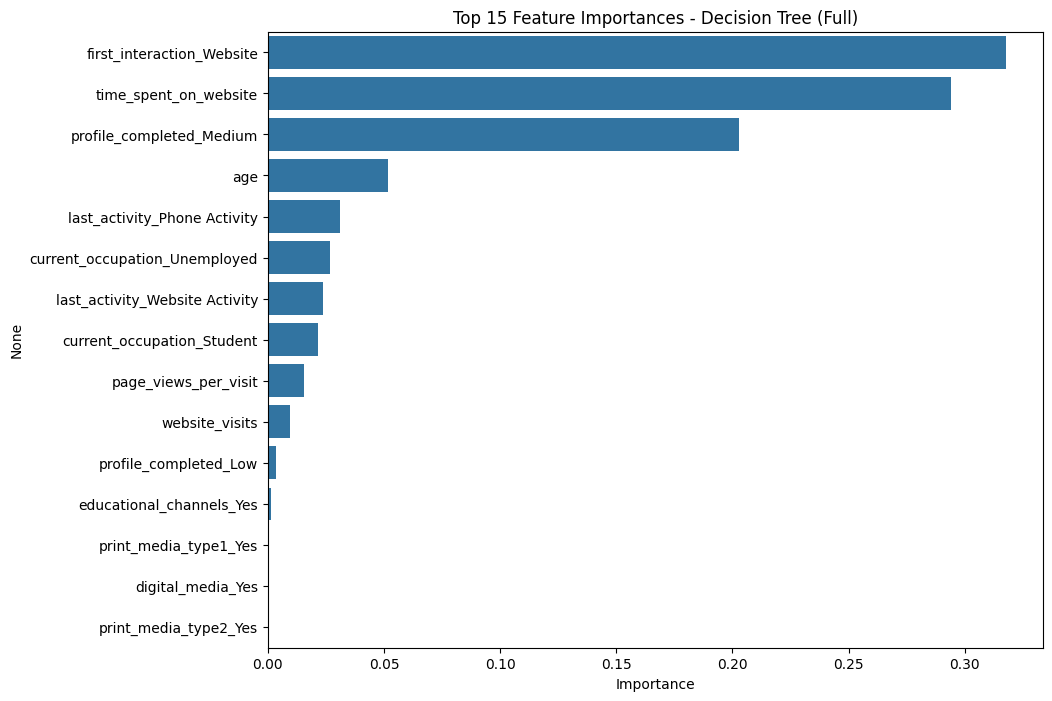

In [ ]:
# Top 15 Important feature
print(pd.DataFrame(pd.Series(r_forest_tuned.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)))
important_feature_tuned = pd.Series(r_forest_tuned.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=important_feature_tuned.values[:15], y=important_feature_tuned.index[:15])
plt.title("Top 15 Feature Importances - Decision Tree (Full)")
plt.xlabel("Importance")
plt.show()


## Actionable Insights and Recommendations

**Based on the top 15 important features:**


*   time_spent on_website is the most important features: the more time that lead spent on website, the more likely they are to convert


*   Current ocupation matter: Professionals convert at a higher noticable rate than the unemployed leads or students


* Referals is the most potenttial channel: Having the highest conversion rate.
* The profile completion is also a strong completion intent: Leads with the high or medium level of profile completion convert more often than the low one.





**Model Comparision:**


*   Both the decision tree model and random forest have been overfitting badly
*    After hyperparameter tuning with `GridSearchCV` (optimizing for Recall on the "Converted" class, since missing out on a lead that would have converted is the costlier mistake for the business), both models generalize far better: training and test performance converge, and Recall on the Converted class improves substantially.
* The **tuned Random Forest** is the recommended model: it matches the tuned Decision Tree's Recall while spreading feature importance across a broader set of predictors, which typically makes it more stable and reliable when applied to new leads.





**Business recomendation:**


*   Emphasize the Website experience to convert the higher conversion rate


1.   Create exclusive promotion only for web experience
2.   Ex: the higher web visits, the higher the promotion, etc



*   Emphasize on the Porfessionals freature


1.   Create courses that emphasize on the carrer growth, upskilling for the workplace , and more
2.   Can create a feature that help professional leads can connect togheter throught channels in the course




*   Grow the refferal channel


1.   refferal channel convert a high conversion rate with small volume
2.   Create more promotion for leads when they reffer someone to the program could be a low cost, high-quality results


*   Encourage the profile completion


1.   the completed profile associated with higher conversion rate
2.   EX: gathering more content through pop-up quiz for extra promotion for leads





*    **Deploy the tuned Random Forest for lead scoring.**


1.   Use it to score incoming leads and route high-probability-to-convert leads to sales representatives first, improving the efficiency of the sales team's time.


